# E-Commerce Sales & Customer Analysis

## Project Overview

This project analyzes an e-commerce sales dataset to understand sales performance, customer behavior, product performance, profitability, geographic trends, and the impact of discounts.

## Business Questions

This project will answer the following questions:

### Sales
- What are the total sales and total profit?
- How many orders were placed?
- What is the average order value?

### Time
- How do sales and profit change over time?
- Which year and month have the highest sales?
- Are there noticeable seasonal trends?

### Products
- Which products generate the most sales?
- Which products generate the most profit?
- Which categories and sub-categories perform best?

### Customers
- Which customers generate the most sales?
- Which customers generate the most profit?
- Who are the highest-value customers?

### Geography
- Which regions generate the most sales?
- Which regions generate the most profit?
- Are there geographic areas with high sales but low profit?

### Discounts
- How does discounting affect profit?
- Are highly discounted products less profitable?
- Which categories are most affected by discounts?

## Dataset

**Source:** Superstore Sales Dataset from Kaggle

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 5)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)


## 3. Load Dataset

In this section, we load the Superstore Sales dataset and perform an initial inspection of its structure, records, columns, and data types.

In [3]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin-1")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 21)


In [5]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Last 5 rows:")
display(df.tail())

Last 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [7]:

print("Column Names:")
print(df.columns.tolist())


Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [8]:

print("Data Types:")
print(df.dtypes)

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


## 4. Data Overview

Before cleaning the dataset, we inspect its structure, statistics, missing values, duplicates, categorical values, date range, and numerical values. This helps us understand the quality and characteristics of the data before performing further analysis.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [10]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:

missing_values = df.isnull().sum()

print(missing_values)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [13]:

categorical_columns = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Category:
['Furniture' 'Office Supplies' 'Technology']

Sub-Category:
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

Region:
['South' 'West' 'Central' 'East']

Segment:
['Consumer' 'Corporate' 'Home Office']

Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [15]:
order_dates = pd.to_datetime(df["Order Date"])

print("Earliest Order Date:", order_dates.min())
print("Latest Order Date:", order_dates.max())

Earliest Order Date: 2014-01-03 00:00:00
Latest Order Date: 2017-12-30 00:00:00


In [16]:
negative_sales = (df["Sales"] < 0).sum()
negative_quantity = (df["Quantity"] < 0).sum()

print("Negative Sales values:", negative_sales)
print("Negative Quantity values:", negative_quantity)

Negative Sales values: 0
Negative Quantity values: 0


In [18]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year




df["Month"] = df["Order Date"].dt.month


df["Month_Name"] = df["Order Date"].dt.month_name()

df["Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)

df["Profit_Margin"] = ((df["Profit"] / df["Sales"]) * 100).round(2)

df["Order_Value"] = df["Sales"]

print("Date-related features:")
display(
    df[
        ["Order Date", "Year", "Month", "Month_Name", "Quarter"]
    ].head(5)
)

print("Profitability features:")
display(
    df[
        ["Sales", "Profit", "Profit_Margin"]
    ].head(5)
)

print("Updated column list:")
print(df.columns.tolist())

Date-related features:


,Order Date,Year,Month,Month_Name,Quarter
0,2016-11-08,2016,11,November,Q4
1,2016-11-08,2016,11,November,Q4
2,2016-06-12,2016,6,June,Q2
3,2015-10-11,2015,10,October,Q4
4,2015-10-11,2015,10,October,Q4


Profitability features:


,Sales,Profit,Profit_Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


Updated column list:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin', 'Order_Value']


## 7. Exploratory Data Analysis

In this section, we calculate key business performance indicators (KPIs) to understand the overall performance of the e-commerce business.

The KPIs cover sales, profitability, orders, customers, products, order value, and quantity sold.

In [20]:
# Calculate overall business KPIs

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_products = df["Product Name"].nunique()

average_order_value = total_sales / total_orders
average_profit_per_order = total_profit / total_orders

overall_profit_margin = (total_profit / total_sales) * 100

total_quantity_sold = df["Quantity"].sum()

print("=== BUSINESS PERFORMANCE SUMMARY ===")

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products Sold: {total_products:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Average Profit per Order: ${average_profit_per_order:,.2f}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")
print(f"Total Quantity Sold: {total_quantity_sold:,}")

=== BUSINESS PERFORMANCE SUMMARY ===
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Total Products Sold: 1,850
Average Order Value: $458.61
Average Profit per Order: $57.18
Overall Profit Margin: 12.47%
Total Quantity Sold: 37,873


## 8. Time-Based Analysis

Time-based analysis helps us understand how sales and profitability change across years, months, and quarters.

This analysis will help identify growth trends, seasonal patterns, and the strongest and weakest periods of business performance.

In [21]:

yearly_summary = (
    df.groupby("Year")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "nunique")
    )
)

yearly_summary["Profit_Margin"] = (
    yearly_summary["Total_Profit"] /
    yearly_summary["Total_Sales"] * 100
).round(2)

yearly_summary = yearly_summary.sort_index()

print("=== YEARLY SALES SUMMARY ===")
display(yearly_summary)

=== YEARLY SALES SUMMARY ===


,Total_Sales,Total_Profit,Total_Orders,Profit_Margin
Year,,,,
2014,484247.4981,49543.9741,969,10.23
2015,470532.5090,61618.6037,1038,13.10
2016,609205.5980,81795.1743,1315,13.43
2017,733215.2552,93439.2696,1687,12.74


In [22]:
monthly_summary = (
    df.groupby("Month")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .sort_index()
)

print("=== MONTHLY SALES TREND ===")
display(monthly_summary)

=== MONTHLY SALES TREND ===


,Total_Sales,Total_Profit
Month,,
1,94924.8356,9134.4461
2,59751.2514,10294.6107
3,205005.4888,28594.6872
4,137762.1286,11587.4363
5,155028.8117,22411.3078
6,152718.6793,21285.7954
7,147238.0970,13832.6648
8,159044.0630,21776.9384
9,307649.9457,36857.4753


In [23]:
monthly_yearly_sales = (
    df.groupby(["Year", "Month"])
    .agg(
        Total_Sales=("Sales", "sum")
    )
    .sort_index()
)

print("=== MONTHLY SALES BY YEAR ===")
display(monthly_yearly_sales)

=== MONTHLY SALES BY YEAR ===


Total_Sales
Year Month             
2014 1       14236.8950
     2        4519.8920
     3       55691.0090
     4       28295.3450
     5       23648.2870
     6       34595.1276
     7       33946.3930
     8       27909.4685
     9       81777.3508
     10      31453.3930
     11      78628.7167
     12      69545.6205
2015 1       18174.0756
     2       11951.4110
     3       38726.2520
     4       34195.2085
     5       30131.6865
     6       24797.2920
     7       28765.3250
     8       36898.3322
     9       64595.9180
     10      31404.9235
     11      75972.5635
     12      74919.5212
2016 1       18542.4910
     2       22978.8150
     3       51715.8750
     4       38750.0390
     5       56987.7280
     6       40344.5340
     7       39261.9630
     8       31115.3743
     9       73410.0249
     10      59687.7450
     11      79411.9658
     12      96999.0430
2017 1       43971.3740
     2       20301.1334
     3       58872.3528
     4       36521.5361
     5       44261.1102
     6       52981.7257
     7       45264.4160
     8       63120.8880
     9       87866.6520
     10      77776.9232
     11     118447.8250
     12      83829.3188

In [24]:
quarterly_summary = (
    df.groupby("Quarter")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

# Arrange quarters in the correct order.
quarter_order = ["Q1", "Q2", "Q3", "Q4"]

quarterly_summary = quarterly_summary.reindex(quarter_order)

print("=== QUARTERLY PERFORMANCE ===")
display(quarterly_summary)

=== QUARTERLY PERFORMANCE ===


,Total_Sales,Total_Profit
Quarter,,
Q1,359681.5758,48023.7440
Q2,445509.6196,55284.5395
Q3,613932.1057,72467.0785
Q4,878077.5592,110621.6597


In [25]:

monthly_performance = (
    df.groupby(["Month", "Month_Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
    .sort_values("Month")
)

print("=== MONTHLY PERFORMANCE ===")
display(monthly_performance)

=== MONTHLY PERFORMANCE ===


,Month,Month_Name,Total_Sales,Total_Profit
0,1,January,94924.8356,9134.4461
1,2,February,59751.2514,10294.6107
2,3,March,205005.4888,28594.6872
3,4,April,137762.1286,11587.4363
4,5,May,155028.8117,22411.3078
5,6,June,152718.6793,21285.7954
6,7,July,147238.0970,13832.6648
7,8,August,159044.0630,21776.9384
8,9,September,307649.9457,36857.4753
9,10,October,200322.9847,31784.0413


In [26]:
# Find the month with the highest sales.
best_sales_month = monthly_performance.loc[
    monthly_performance["Total_Sales"].idxmax()
]

# Find the month with the lowest sales.
worst_sales_month = monthly_performance.loc[
    monthly_performance["Total_Sales"].idxmin()
]

# Find the month with the highest profit.
best_profit_month = monthly_performance.loc[
    monthly_performance["Total_Profit"].idxmax()
]

print("=== BEST AND WORST PERFORMING MONTHS ===")

print(
    f"Highest Sales: {best_sales_month['Month_Name']} "
    f"(${best_sales_month['Total_Sales']:,.2f})"
)

print(
    f"Lowest Sales: {worst_sales_month['Month_Name']} "
    f"(${worst_sales_month['Total_Sales']:,.2f})"
)

print(
    f"Highest Profit: {best_profit_month['Month_Name']} "
    f"(${best_profit_month['Total_Profit']:,.2f})"
)

=== BEST AND WORST PERFORMING MONTHS ===
Highest Sales: November ($352,461.07)
Lowest Sales: February ($59,751.25)
Highest Profit: December ($43,369.19)


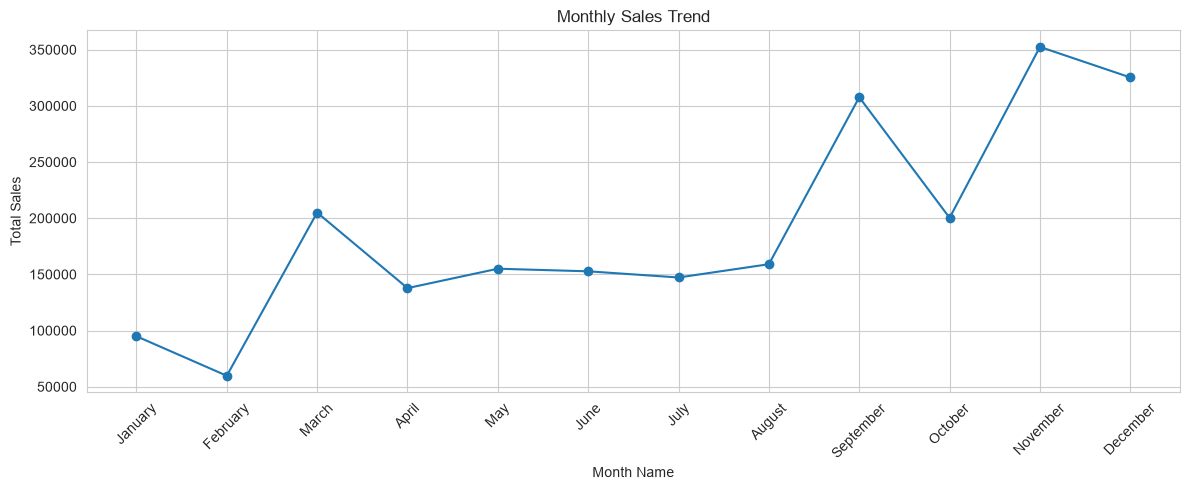

In [27]:

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_chart_data = (
    df.groupby(["Month", "Month_Name"])["Sales"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_chart_data["Month_Name"],
    monthly_chart_data["Sales"],
    marker="o"
)

ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month Name")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

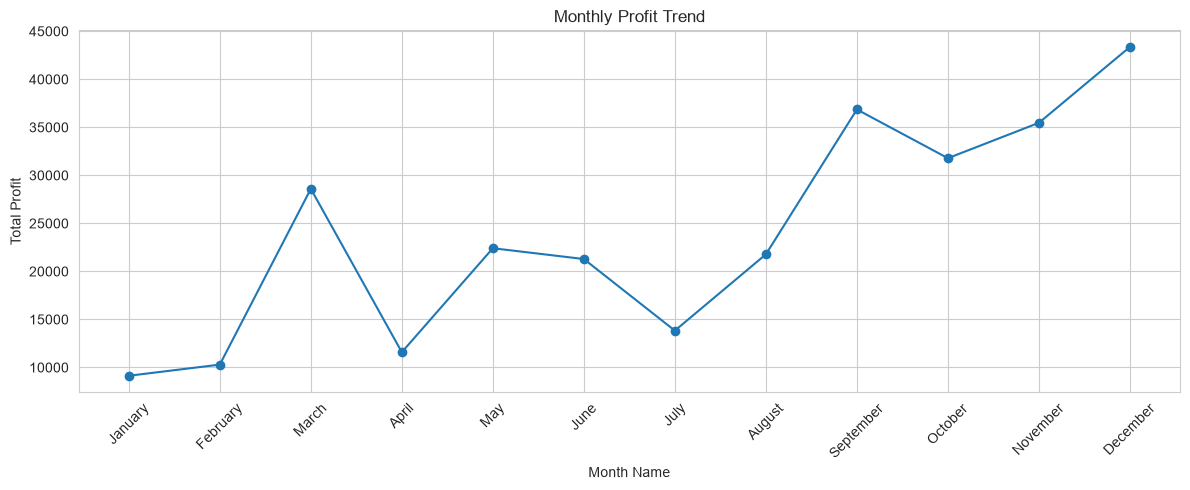

In [28]:

monthly_profit_chart = (
    df.groupby(["Month", "Month_Name"])["Profit"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_profit_chart["Month_Name"],
    monthly_profit_chart["Profit"],
    marker="o"
)

ax.set_title("Monthly Profit Trend")
ax.set_xlabel("Month Name")
ax.set_ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../images/monthly_profit_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:

best_year = yearly_summary["Total_Sales"].idxmax()
best_year_sales = yearly_summary.loc[best_year, "Total_Sales"]
best_year_profit = yearly_summary.loc[best_year, "Total_Profit"]

strongest_quarter = quarterly_summary["Total_Sales"].idxmax()
strongest_quarter_sales = quarterly_summary.loc[
    strongest_quarter, "Total_Sales"
]

strongest_month = best_sales_month["Month_Name"]
strongest_month_sales = best_sales_month["Total_Sales"]

weakest_month = worst_sales_month["Month_Name"]
weakest_month_sales = worst_sales_month["Total_Sales"]

print("=== KEY TIME-BASED FINDINGS ===")

print(
    f"Best Year: {best_year} "
    f"with sales of ${best_year_sales:,.2f}"
)

print(
    f"Strongest Quarter: {strongest_quarter} "
    f"with sales of ${strongest_quarter_sales:,.2f}"
)

print(
    f"Strongest Month: {strongest_month} "
    f"with sales of ${strongest_month_sales:,.2f}"
)

print(
    f"Weakest Month: {weakest_month} "
    f"with sales of ${weakest_month_sales:,.2f}"
)

=== KEY TIME-BASED FINDINGS ===
Best Year: 2017 with sales of $733,215.26
Strongest Quarter: Q4 with sales of $878,077.56
Strongest Month: November with sales of $352,461.07
Weakest Month: February with sales of $59,751.25


## 9. Product Analysis

Product analysis helps us understand which categories, sub-categories, and individual products drive sales and profit.

This section identifies high-performing products, loss-making sub-categories, and products that generate high sales but relatively low or negative profit.

In [30]:

category_analysis = (
    df.groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
)

category_analysis["Profit_Margin"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"] * 100
).round(2)
category_analysis = category_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

print("=== CATEGORY ANALYSIS ===")
display(category_analysis)

=== CATEGORY ANALYSIS ===


,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin
Category,,,,,
Technology,836154.0330,145454.9481,6939,1544,17.40
Furniture,741999.7953,18451.2728,8028,1764,2.49
Office Supplies,719047.0320,122490.8008,22906,3742,17.04


In [31]:

subcategory_analysis = (
    df.groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
)

subcategory_analysis["Profit_Margin"] = (
    subcategory_analysis["Total_Profit"] /
    subcategory_analysis["Total_Sales"] * 100
).round(2)

subcategory_analysis = subcategory_analysis.sort_values(
    "Total_Profit",
    ascending=False
)

print("=== SUB-CATEGORY ANALYSIS ===")
display(subcategory_analysis)

=== SUB-CATEGORY ANALYSIS ===


,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
Sub-Category,,,,
Copiers,149528.0300,55617.8249,234,37.20
Phones,330007.0540,44515.7306,3289,13.49
Accessories,167380.3180,41936.6357,2976,25.05
Paper,78479.2060,34053.5693,5178,43.39
Binders,203412.7330,30221.7633,5974,14.86
Chairs,328449.1030,26590.1663,2356,8.10
Storage,223843.6080,21278.8264,3158,9.51
Appliances,107532.1610,18138.0054,1729,16.87
Furnishings,91705.1640,13059.1436,3563,14.24


In [32]:

loss_making_subcategories = subcategory_analysis[
    subcategory_analysis["Total_Profit"] < 0
]

print("=== LOSS-MAKING SUB-CATEGORIES ===")
display(loss_making_subcategories)

=== LOSS-MAKING SUB-CATEGORIES ===


,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin
Sub-Category,,,,
Supplies,46673.5380,-1189.0995,647,-2.55
Bookcases,114879.9963,-3472.5560,868,-3.02
Tables,206965.5320,-17725.4811,1241,-8.56


In [34]:

top_products_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("=== TOP 10 PRODUCTS BY SALES ===")
display(top_products_sales)

=== TOP 10 PRODUCTS BY SALES ===


Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [35]:


top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("=== TOP 10 PRODUCTS BY PROFIT ===")
display(top_products_profit)

=== TOP 10 PRODUCTS BY PROFIT ===


Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [36]:

product_analysis = (
    df.groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
)

product_analysis["Profit_Margin"] = (
    product_analysis["Total_Profit"] /
    product_analysis["Total_Sales"] * 100
).round(2)

sales_median = product_analysis["Total_Sales"].median()

# Identify products with relatively high sales but poor profitability.
problem_products = product_analysis[
    (product_analysis["Total_Sales"] > sales_median) &
    (product_analysis["Profit_Margin"] < 5)
].sort_values(
    "Total_Sales",
    ascending=False
)

print("=== HIGH-SALES BUT LOW/NEGATIVE-PROFIT PRODUCTS ===")
display(problem_products.head(20))

=== HIGH-SALES BUT LOW/NEGATIVE-PROFIT PRODUCTS ===


,Total_Sales,Total_Profit,Profit_Margin
Product Name,,,
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1.811078e+03,-8.00
HON 5400 Series Task Chairs for Big and Tall,21870.5760,5.684342e-14,0.00
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000,7.609800e+02,4.00
GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,-10.45
High Speed Automatic Electric Letter Opener,17030.3120,-2.620048e+02,-1.54
Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4.589973e+03,-27.27
Martin Yale Chadless Opener Electric Letter Opener,16656.2000,-1.299184e+03,-7.80
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",15610.9656,-6.695448e+02,-4.29
Bretford Rectangular Conference Table Tops,12995.2915,-3.272331e+02,-2.52


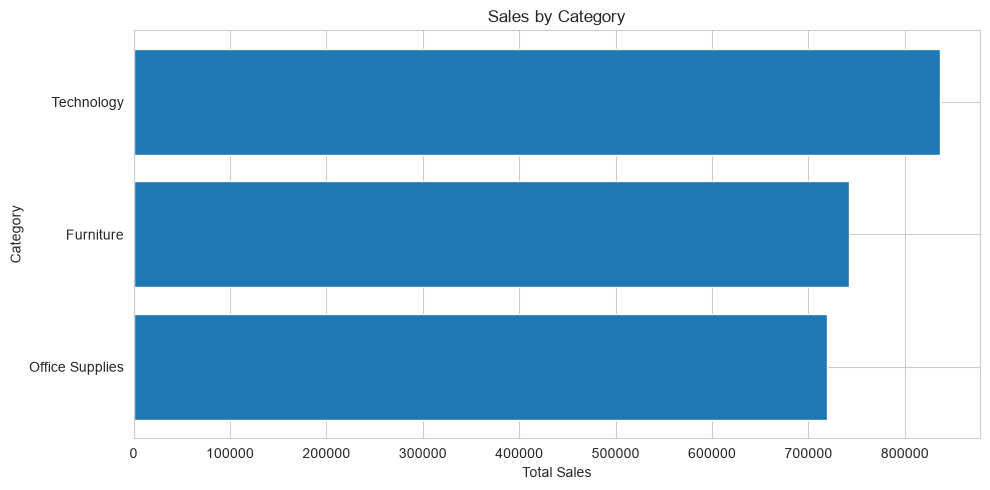

In [37]:

fig, ax = plt.subplots(figsize=(10, 5))

category_sales = category_analysis.sort_values("Total_Sales")

ax.barh(
    category_sales.index,
    category_sales["Total_Sales"]
)

ax.set_title("Sales by Category")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../images/category_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

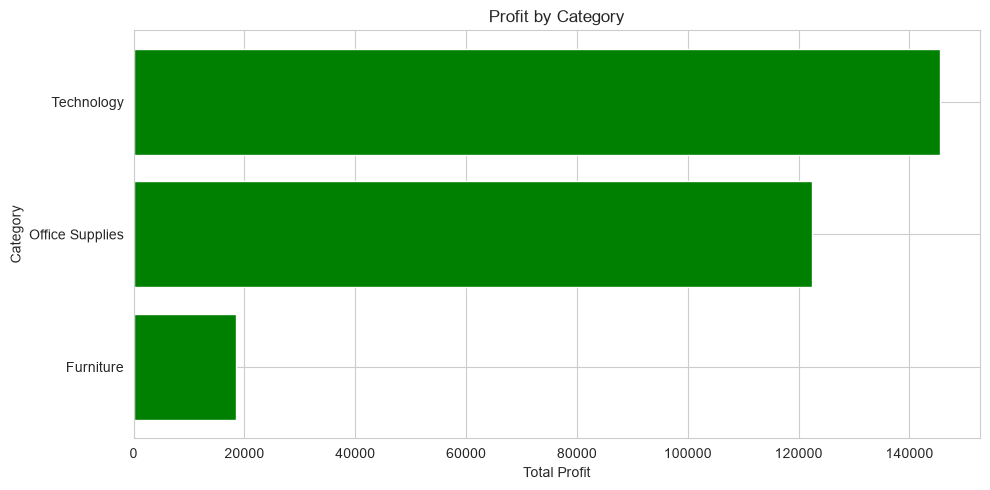

In [38]:
# Green represents positive profit and red represents negative profit.

category_profit = category_analysis.sort_values("Total_Profit")

profit_colors = [
    "green" if value >= 0 else "red"
    for value in category_profit["Total_Profit"]
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    category_profit.index,
    category_profit["Total_Profit"],
    color=profit_colors
)

ax.set_title("Profit by Category")
ax.set_xlabel("Total Profit")
ax.set_ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../images/category_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

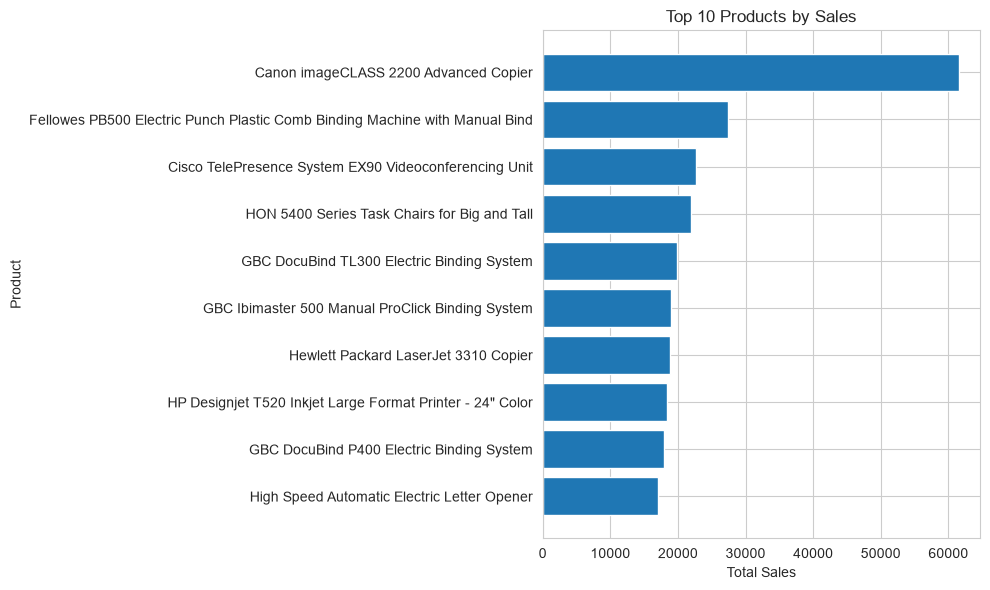

In [39]:

top_sales_chart = top_products_sales.sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_sales_chart.index,
    top_sales_chart.values
)

ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../images/top_products_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

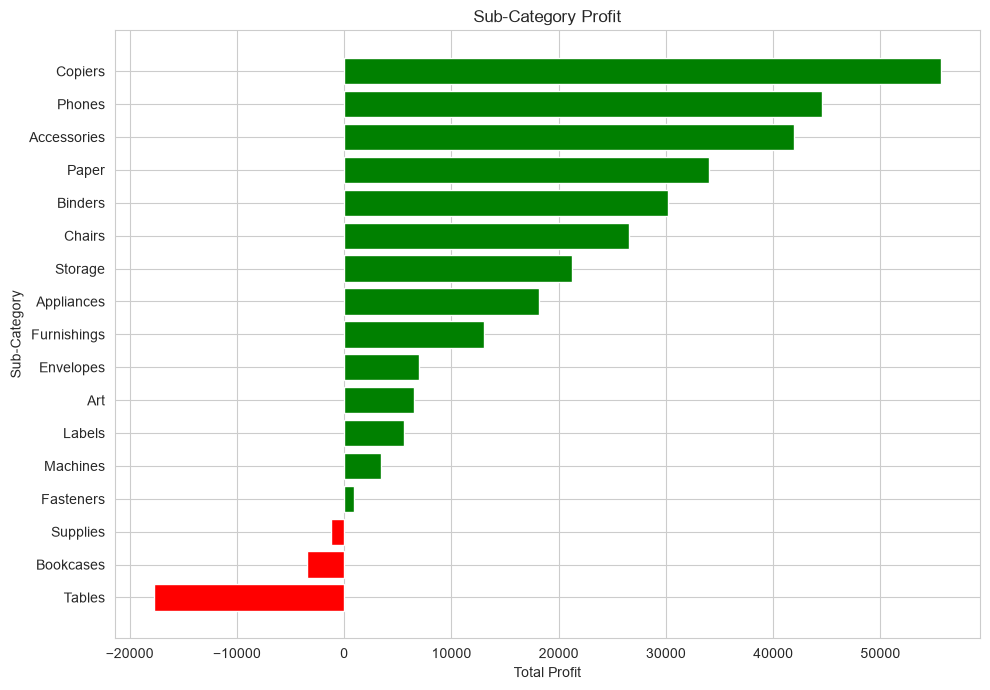

In [40]:
# Profit by Sub-Category
# Green represents positive profit and red represents negative profit.

subcategory_profit = subcategory_analysis.sort_values("Total_Profit")

profit_colors = [
    "green" if value >= 0 else "red"
    for value in subcategory_profit["Total_Profit"]
]

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    subcategory_profit.index,
    subcategory_profit["Total_Profit"],
    color=profit_colors
)

ax.set_title("Sub-Category Profit")
ax.set_xlabel("Total Profit")
ax.set_ylabel("Sub-Category")

plt.tight_layout()

plt.savefig(
    "../images/subcategory_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:


best_sales_category = category_analysis["Total_Sales"].idxmax()
best_sales_category_value = category_analysis.loc[
    best_sales_category, "Total_Sales"
]

best_profit_category = category_analysis["Total_Profit"].idxmax()
best_profit_category_value = category_analysis.loc[
    best_profit_category, "Total_Profit"
]

worst_profit_subcategory = subcategory_analysis["Total_Profit"].idxmin()
worst_profit_subcategory_value = subcategory_analysis.loc[
    worst_profit_subcategory, "Total_Profit"
]

best_sales_subcategory = subcategory_analysis["Total_Sales"].idxmax()

print("=== PRODUCT ANALYSIS KEY FINDINGS ===")

print(
    f"Highest Sales Category: {best_sales_category} "
    f"(${best_sales_category_value:,.2f})"
)

print(
    f"Highest Profit Category: {best_profit_category} "
    f"(${best_profit_category_value:,.2f})"
)

print(
    f"Most Loss-Making Sub-Category: {worst_profit_subcategory} "
    f"(${worst_profit_subcategory_value:,.2f})"
)

print(
    f"Highest Sales Sub-Category: {best_sales_subcategory}"
)

print(
    f"Number of High-Sales/Low-Profit Products: "
    f"{len(problem_products)}"
)

=== PRODUCT ANALYSIS KEY FINDINGS ===
Highest Sales Category: Technology ($836,154.03)
Highest Profit Category: Technology ($145,454.95)
Most Loss-Making Sub-Category: Tables ($-17,725.48)
Highest Sales Sub-Category: Phones
Number of High-Sales/Low-Profit Products: 255


## 10. Customer Analysis

Customer analysis helps us understand customer value, purchasing behavior, profitability, and the distribution of customers across different value segments.

This analysis identifies high-value customers and helps determine whether customers who spend more also generate greater profit.

In [42]:
# PART A — Customer-Level Aggregation
# Aggregate transaction-level data into one row per customer.

customer_df = (
    df.groupby("Customer ID")
    .agg(
        Customer_Name=("Customer Name", "first"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
)

customer_df["Average_Order_Value"] = (
    customer_df["Total_Sales"] /
    customer_df["Total_Orders"]
).round(2)

customer_df["Profit_Margin"] = (
    customer_df["Total_Profit"] /
    customer_df["Total_Sales"] * 100
).round(2)

print("Customer DataFrame Shape:", customer_df.shape)

print("\n=== FIRST 5 CUSTOMERS ===")
display(customer_df.head())

Customer DataFrame Shape: (793, 7)

=== FIRST 5 CUSTOMERS ===


,Customer_Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Average_Order_Value,Profit_Margin
Customer ID,,,,,,,
AA-10315,Alex Avila,5563.560,-362.8825,5,30,1112.71,-6.52
AA-10375,Allen Armold,1056.390,277.3824,9,41,117.38,26.26
AA-10480,Andrew Allen,1790.512,435.8274,4,36,447.63,24.34
AA-10645,Anna Andreadi,5086.935,857.8033,6,64,847.82,16.86
AB-10015,Aaron Bergman,886.156,129.3465,3,13,295.39,14.60


In [43]:
# PART B — Customer Summary Statistics

average_orders_per_customer = customer_df["Total_Orders"].mean()

average_spending_per_customer = customer_df["Total_Sales"].mean()

average_profit_per_customer = customer_df["Total_Profit"].mean()

highest_sales_customer = customer_df["Total_Sales"].idxmax()

highest_profit_customer = customer_df["Total_Profit"].idxmax()

most_orders_customer = customer_df["Total_Orders"].idxmax()


print("=== CUSTOMER SUMMARY STATISTICS ===")

print(
    f"Average Orders per Customer: "
    f"{average_orders_per_customer:.2f}"
)

print(
    f"Average Total Spending per Customer: "
    f"${average_spending_per_customer:,.2f}"
)

print(
    f"Average Profit per Customer: "
    f"${average_profit_per_customer:,.2f}"
)

print(
    f"Customer with Highest Total Sales: "
    f"{highest_sales_customer}"
)

print(
    f"Customer with Highest Total Profit: "
    f"{highest_profit_customer}"
)

print(
    f"Customer with Most Orders: "
    f"{most_orders_customer}"
)

=== CUSTOMER SUMMARY STATISTICS ===
Average Orders per Customer: 6.32
Average Total Spending per Customer: $2,896.85
Average Profit per Customer: $361.16
Customer with Highest Total Sales: SM-20320
Customer with Highest Total Profit: TC-20980
Customer with Most Orders: EP-13915


In [44]:
# Find the sales values corresponding to the 20th and 80th percentiles.

low_boundary = customer_df["Total_Sales"].quantile(0.20)
high_boundary = customer_df["Total_Sales"].quantile(0.80)

print("20th Percentile:", low_boundary)
print("80th Percentile:", high_boundary)

20th Percentile: 961.5406
80th Percentile: 4282.6344


In [45]:
# Assign each customer to a value segment based on total sales.

customer_df["Customer_Segment"] = pd.cut(
    customer_df["Total_Sales"],
    bins=[
        float("-inf"),
        low_boundary,
        high_boundary,
        float("inf")
    ],
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
    ]
)

print("=== CUSTOMER SEGMENT COUNTS ===")
display(
    customer_df["Customer_Segment"]
    .value_counts()
    .sort_index()
)

=== CUSTOMER SEGMENT COUNTS ===


Customer_Segment
Low Value       159
Medium Value    475
High Value      159
Name: count, dtype: int64

In [46]:
segment_summary = (
    customer_df
    .groupby("Customer_Segment", observed=False)
    .agg(
        Customer_Count=("Total_Sales", "count"),
        Average_Sales=("Total_Sales", "mean"),
        Average_Profit=("Total_Profit", "mean"),
        Average_Orders=("Total_Orders", "mean")
    )
)

print("=== CUSTOMER SEGMENT PERFORMANCE ===")
display(segment_summary)

=== CUSTOMER SEGMENT PERFORMANCE ===


,Customer_Count,Average_Sales,Average_Profit,Average_Orders
Customer_Segment,,,,
Low Value,159,531.625225,64.862025,4.075472
Medium Value,475,2329.701312,222.409727,6.484211
High Value,159,6956.379409,1071.945531,8.056604


In [47]:

top_customers_sales = (
    customer_df
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

print("=== TOP 10 CUSTOMERS BY TOTAL SALES ===")

display(
    top_customers_sales[
        [
            "Customer_Name",
            "Total_Sales",
            "Total_Profit",
            "Total_Orders",
            "Average_Order_Value"
        ]
    ]
)

=== TOP 10 CUSTOMERS BY TOTAL SALES ===


,Customer_Name,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value
Customer ID,,,,,
SM-20320,Sean Miller,25043.050,-1980.7393,5,5008.61
TC-20980,Tamara Chand,19052.218,8981.3239,5,3810.44
RB-19360,Raymond Buch,15117.339,6976.0959,6,2519.56
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,3648.90
AB-10105,Adrian Barton,14473.571,5444.8055,10,1447.36
KL-16645,Ken Lonsdale,14175.229,806.8550,12,1181.27
SC-20095,Sanjit Chand,14142.334,5757.4119,9,1571.37
HL-15040,Hunter Lopez,12873.298,5622.4292,6,2145.55
SE-20110,Sanjit Engle,12209.438,2650.6769,11,1109.95


In [48]:
top_customers_profit = (
    customer_df
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

print("=== TOP 10 CUSTOMERS BY TOTAL PROFIT ===")

display(
    top_customers_profit[
        [
            "Customer_Name",
            "Total_Sales",
            "Total_Profit",
            "Total_Orders",
            "Average_Order_Value"
        ]
    ]
)

=== TOP 10 CUSTOMERS BY TOTAL PROFIT ===


,Customer_Name,Total_Sales,Total_Profit,Total_Orders,Average_Order_Value
Customer ID,,,,,
TC-20980,Tamara Chand,19052.218,8981.3239,5,3810.44
RB-19360,Raymond Buch,15117.339,6976.0959,6,2519.56
SC-20095,Sanjit Chand,14142.334,5757.4119,9,1571.37
HL-15040,Hunter Lopez,12873.298,5622.4292,6,2145.55
AB-10105,Adrian Barton,14473.571,5444.8055,10,1447.36
TA-21385,Tom Ashbrook,14595.620,4703.7883,4,3648.90
CM-12385,Christopher Martinez,8954.020,3899.8904,4,2238.50
KD-16495,Keith Dawkins,8181.256,3038.6254,12,681.77
AR-10540,Andy Reiter,6608.448,2884.6208,6,1101.41


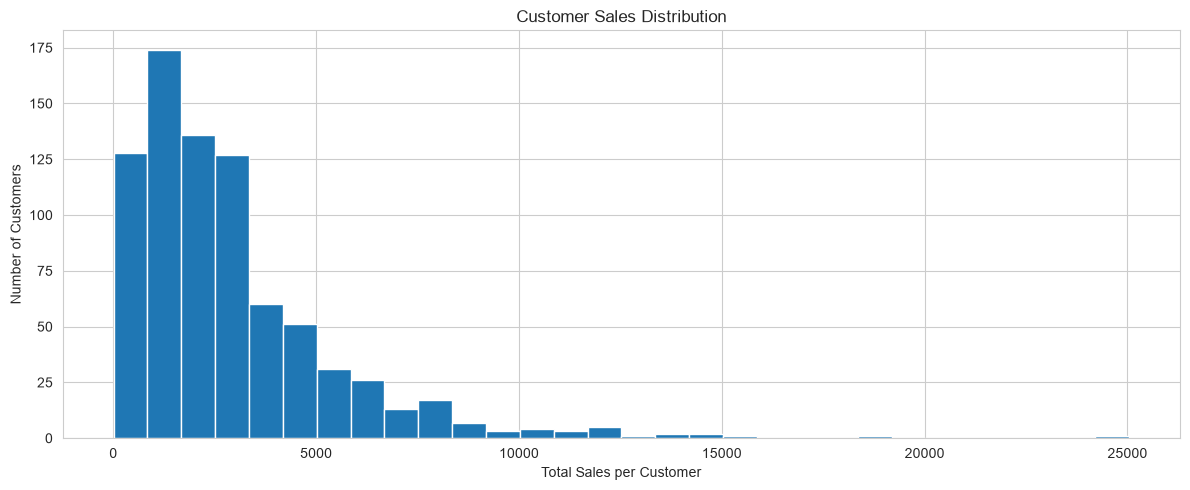

In [49]:
# Visualization 7 — Distribution of total sales per customer.

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    customer_df["Total_Sales"],
    bins=30
)

ax.set_title("Customer Sales Distribution")
ax.set_xlabel("Total Sales per Customer")
ax.set_ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../images/customer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
# Extract the actual customer-analysis findings for our business insights.

total_customers = len(customer_df)

high_value_count = (
    customer_df["Customer_Segment"] == "High Value"
).sum()

high_value_percentage = (
    high_value_count / total_customers
) * 100

high_value_profit = customer_df.loc[
    customer_df["Customer_Segment"] == "High Value",
    "Total_Profit"
].sum()

high_value_sales = customer_df.loc[
    customer_df["Customer_Segment"] == "High Value",
    "Total_Sales"
].sum()

high_value_profit_margin = (
    high_value_profit / high_value_sales
) * 100

average_orders = customer_df["Total_Orders"].mean()

highest_sales_customer_name = customer_df.loc[
    highest_sales_customer,
    "Customer_Name"
]

highest_profit_customer_name = customer_df.loc[
    highest_profit_customer,
    "Customer_Name"
]

most_orders_customer_name = customer_df.loc[
    most_orders_customer,
    "Customer_Name"
]


print("=== CUSTOMER ANALYSIS KEY FINDINGS ===")

print(
    f"High-Value Customers: {high_value_count:,} "
    f"({high_value_percentage:.2f}% of customers)"
)

print(
    f"High-Value Customer Profit Margin: "
    f"{high_value_profit_margin:.2f}%"
)

print(
    f"Average Orders per Customer: "
    f"{average_orders:.2f}"
)

print(
    f"Highest Sales Customer: "
    f"{highest_sales_customer_name} "
    f"(${customer_df.loc[highest_sales_customer, 'Total_Sales']:,.2f})"
)

print(
    f"Highest Profit Customer: "
    f"{highest_profit_customer_name} "
    f"(${customer_df.loc[highest_profit_customer, 'Total_Profit']:,.2f})"
)

print(
    f"Most Frequent Customer: "
    f"{most_orders_customer_name} "
    f"({customer_df.loc[most_orders_customer, 'Total_Orders']} orders)"
)

=== CUSTOMER ANALYSIS KEY FINDINGS ===
High-Value Customers: 159 (20.05% of customers)
High-Value Customer Profit Margin: 15.41%
Average Orders per Customer: 6.32
Highest Sales Customer: Sean Miller ($25,043.05)
Highest Profit Customer: Tamara Chand ($8,981.32)
Most Frequent Customer: Emily Phan (17 orders)


## 11. Geographic Analysis

Geographic analysis helps us understand how business performance varies across regions and states.

This section identifies high-performing and loss-making locations and examines whether strong sales in a location also result in strong profitability.

In [54]:
regional_analysis = (df.groupby("Region")
                    .agg(
                        Total_sales = ("Sales","sum"),
                        Total_profit= ("Profit","sum"),
                        Total_order = ("Order ID","nunique")))

regional_analysis["Prifit_Margin"] = (
    regional_analysis["Total_profit"]/
    regional_analysis["Total_sales"]* 100
).round(2)

regional_analysis = regional_analysis.sort_values(
    "Total_sales",
    ascending = False
)
print("=== REGIONAL PERFORMANCE ===")
display(regional_analysis)

=== REGIONAL PERFORMANCE ===


,Total_sales,Total_profit,Total_order,Prifit_Margin
Region,,,,
West,725457.8245,108418.4489,1611,14.94
East,678781.2400,91522.7800,1401,13.48
Central,501239.8908,39706.3625,1175,7.92
South,391721.9050,46749.4303,822,11.93


In [56]:
state_analysis = ( df.groupby("State")
                   .agg(
                       Total_sales = ("Sales","sum"),
                       Total_profit = ("Profit","sum")
                   ))
state_analysis["Profit_Margin"] = (
    state_analysis["Total_profit"]/
    state_analysis["Total_sales"] * 100
).round(2)

print("=== STATE PERFORMANCE ===")
display(state_analysis.sort_values("Total_sales", ascending=False))

=== STATE PERFORMANCE ===


,Total_sales,Total_profit,Profit_Margin
State,,,
California,457687.6315,76381.3871,16.69
New York,310876.2710,74038.5486,23.82
Texas,170188.0458,-25729.3563,-15.12
Washington,138641.2700,33402.6517,24.09
Pennsylvania,116511.9140,-15559.9603,-13.35
Florida,89473.7080,-3399.3017,-3.80
Illinois,80166.1010,-12607.8870,-15.73
Ohio,78258.1360,-16971.3766,-21.69
Michigan,76269.6140,24463.1876,32.07


In [60]:
top_10_states_sales = (
    state_analysis.sort_values(
        "Total_sales", ascending =False
    )
).head(10)
print("=== TOP 10 STATES BY SALES ===")
display(top_10_states_sales)

=== TOP 10 STATES BY SALES ===


,Total_sales,Total_profit,Profit_Margin
State,,,
California,457687.6315,76381.3871,16.69
New York,310876.2710,74038.5486,23.82
Texas,170188.0458,-25729.3563,-15.12
Washington,138641.2700,33402.6517,24.09
Pennsylvania,116511.9140,-15559.9603,-13.35
Florida,89473.7080,-3399.3017,-3.80
Illinois,80166.1010,-12607.8870,-15.73
Ohio,78258.1360,-16971.3766,-21.69
Michigan,76269.6140,24463.1876,32.07


In [61]:
top_10_states_profit= (
    state_analysis.sort_values(
        "Total_profit", ascending =False
    )
).head(10)
print("=== TOP 10 STATES BY PROFIT ===")
display(top_10_states_profit)

=== TOP 10 STATES BY PROFIT ===


,Total_sales,Total_profit,Profit_Margin
State,,,
California,457687.6315,76381.3871,16.69
New York,310876.2710,74038.5486,23.82
Washington,138641.2700,33402.6517,24.09
Michigan,76269.6140,24463.1876,32.07
Virginia,70636.7200,18597.9504,26.33
Indiana,53555.3600,18382.9363,34.33
Georgia,49095.8400,16250.0433,33.10
Kentucky,36591.7500,11199.6966,30.61
Minnesota,29863.1500,10823.1874,36.24


In [62]:
bottom_10_states_profit= (
    state_analysis.sort_values(
        "Total_profit", ascending =True
    )
).head(10)


print("=== BOTTOM 10 STATES BY PROFIT ===")
display(bottom_10_states_profit)

=== BOTTOM 10 STATES BY PROFIT ===


,Total_sales,Total_profit,Profit_Margin
State,,,
Texas,170188.0458,-25729.3563,-15.12
Ohio,78258.1360,-16971.3766,-21.69
Pennsylvania,116511.9140,-15559.9603,-13.35
Illinois,80166.1010,-12607.8870,-15.73
North Carolina,55603.1640,-7490.9122,-13.47
Colorado,32108.1180,-6527.8579,-20.33
Tennessee,30661.8730,-5341.6936,-17.42
Arizona,35282.0010,-3427.9246,-9.72
Florida,89473.7080,-3399.3017,-3.80


In [64]:
state_sales_median = state_analysis["Total_sales"].median()

problem_states = state_analysis[
    (state_analysis["Total_sales"] > state_sales_median)&
    (state_analysis["Total_profit"] < 5)
].sort_values(
    "Total_sales", ascending = False
)
print("=== HIGH-SALES BUT LOW-PROFIT STATES ===")
display(problem_states)


=== HIGH-SALES BUT LOW-PROFIT STATES ===


,Total_sales,Total_profit,Profit_Margin
State,,,
Texas,170188.0458,-25729.3563,-15.12
Pennsylvania,116511.9140,-15559.9603,-13.35
Florida,89473.7080,-3399.3017,-3.80
Illinois,80166.1010,-12607.8870,-15.73
Ohio,78258.1360,-16971.3766,-21.69
North Carolina,55603.1640,-7490.9122,-13.47
Arizona,35282.0010,-3427.9246,-9.72
Colorado,32108.1180,-6527.8579,-20.33
Tennessee,30661.8730,-5341.6936,-17.42


In [68]:
region_category_sales = pd.pivot_table(
    df,
    values="Sales",
    index= "Region",
    columns="Category",
    aggfunc = "sum"
)
print("=== SALES BY REGION AND CATEGORY ===")
display(region_category_sales)

=== SALES BY REGION AND CATEGORY ===


Category,Furniture,Office Supplies,Technology
Region,,,
Central,163797.1638,167026.415,170416.312
East,208291.2040,205516.055,264973.981
South,117298.6840,125651.313,148771.908
West,252612.7435,220853.249,251991.832


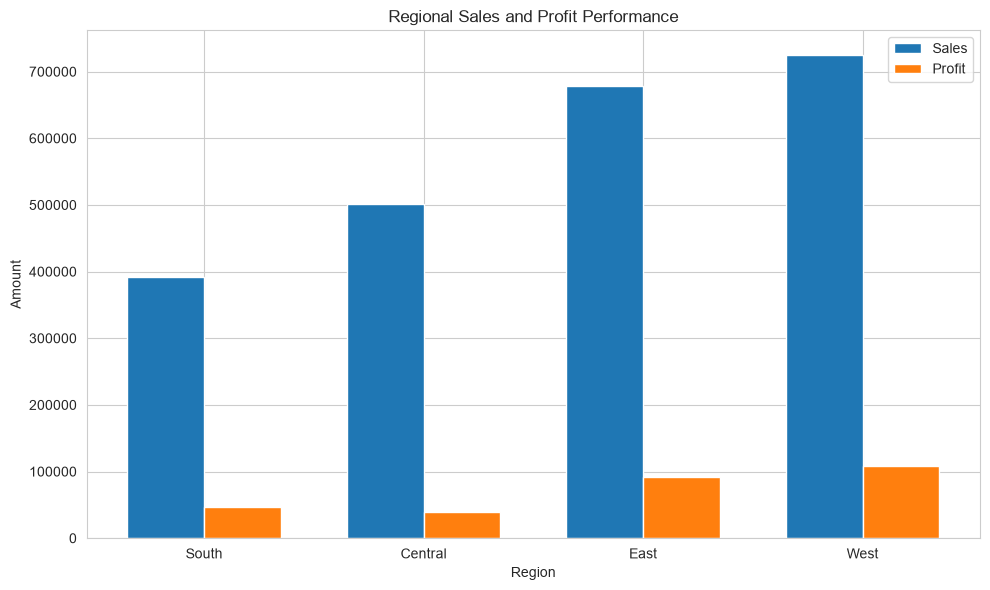

In [71]:
regional_chart = regional_analysis.sort_values("Total_sales")

fig, ax = plt.subplots(figsize=(10,6))
x= np.arange(len(regional_chart))
width=0.35

ax.bar(
    x- width/2,
    regional_chart["Total_sales"],
    width,
    label= "Sales"
)
ax.bar(
    x+ width/2,
    regional_chart["Total_profit"],
    width,
    label = "Profit"
)
ax.set_title("Regional Sales and Profit Performance")
ax.set_xlabel("Region")
ax.set_ylabel("Amount")

ax.set_xticks(x)
ax.set_xticklabels(regional_chart.index)

ax.legend()

plt.tight_layout()

plt.savefig(
    "../images/regional_performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:

best_sales_region = regional_analysis["Total_sales"].idxmax()
best_sales_region_value = regional_analysis.loc[
    best_sales_region, "Total_sales"
]

best_profit_region = regional_analysis["Total_profit"].idxmax()
best_profit_region_value = regional_analysis.loc[
    best_profit_region, "Total_profit"
]

worst_profit_region = regional_analysis["Total_profit"].idxmin()
worst_profit_region_value = regional_analysis.loc[
    worst_profit_region, "Total_profit"
]

best_sales_state = state_analysis["Total_sales"].idxmax()
best_sales_state_value = state_analysis.loc[
    best_sales_state, "Total_sales"
]

best_profit_state = state_analysis["Total_profit"].idxmax()
best_profit_state_value = state_analysis.loc[
    best_profit_state, "Total_profit"
]

loss_making_state_count = (
    state_analysis["Total_profit"] < 0
).sum()

print("=== GEOGRAPHIC ANALYSIS KEY FINDINGS ===")

print(
    f"Highest Sales Region: {best_sales_region} "
    f"(${best_sales_region_value:,.2f})"
)

print(
    f"Highest Profit Region: {best_profit_region} "
    f"(${best_profit_region_value:,.2f})"
)

print(
    f"Lowest Profit Region: {worst_profit_region} "
    f"(${worst_profit_region_value:,.2f})"
)

print(
    f"Highest Sales State: {best_sales_state} "
    f"(${best_sales_state_value:,.2f})"
)

print(
    f"Highest Profit State: {best_profit_state} "
    f"(${best_profit_state_value:,.2f})"
)

print(
    f"Number of Loss-Making States: "
    f"{loss_making_state_count}"
)

print(
    f"Number of High-Sales/Low-Profit States: "
    f"{len(problem_states)}"
)

=== GEOGRAPHIC ANALYSIS KEY FINDINGS ===
Highest Sales Region: West ($725,457.82)
Highest Profit Region: West ($108,418.45)
Lowest Profit Region: Central ($39,706.36)
Highest Sales State: California ($457,687.63)
Highest Profit State: California ($76,381.39)
Number of Loss-Making States: 10
Number of High-Sales/Low-Profit States: 9


In [75]:
correlation_matrix = df[
    ["Sales", "Profit","Discount", "Quantity"]
].corr()
print("=== CORRELATION MATRIX ===")
display(correlation_matrix)

=== CORRELATION MATRIX ===


,Sales,Profit,Discount,Quantity
Sales,1.000000,0.479064,-0.028190,0.200795
Profit,0.479064,1.000000,-0.219487,0.066253
Discount,-0.028190,-0.219487,1.000000,0.008623
Quantity,0.200795,0.066253,0.008623,1.000000


In [76]:
discount_profit_corr = correlation_matrix.loc["Discount", "Profit"]
discount_sales_corr = correlation_matrix.loc["Discount", "Sales"]
sales_profit_corr = correlation_matrix.loc["Sales", "Profit"]
quantity_sales_corr = correlation_matrix.loc["Quantity", "Sales"]

print("=== KEY CORRELATIONS ===")

print(f"Discount vs Profit: {discount_profit_corr:.3f}")
print(f"Discount vs Sales: {discount_sales_corr:.3f}")
print(f"Sales vs Profit: {sales_profit_corr:.3f}")
print(f"Quantity vs Sales: {quantity_sales_corr:.3f}")

=== KEY CORRELATIONS ===
Discount vs Profit: -0.219
Discount vs Sales: -0.028
Sales vs Profit: 0.479
Quantity vs Sales: 0.201


In [77]:

df["Discount_Range"] = pd.cut(
    df["Discount"],
    bins=[
        -0.0001,
        0,
        0.20,
        0.40,
        float("inf")
    ],
    labels=[
        "No Discount",
        "Low Discount",
        "Medium Discount",
        "High Discount"
    ]
)

print("=== DISCOUNT RANGE COUNTS ===")
display(
    df["Discount_Range"]
    .value_counts()
    .sort_index()
)

=== DISCOUNT RANGE COUNTS ===


Discount_Range
No Discount        4798
Low Discount       3803
Medium Discount     460
High Discount       933
Name: count, dtype: int64

In [78]:
discount_analysis = (
    df.groupby("Discount_Range", observed=False)
    .agg(
        Average_Profit=("Profit", "mean"),
        Average_Sales=("Sales", "mean"),
        Total_Orders=("Order ID", "nunique"),
        Average_Profit_Margin=("Profit_Margin", "mean")
    )
)

discount_analysis["Average_Profit"] = (
    discount_analysis["Average_Profit"].round(2)
)

discount_analysis["Average_Sales"] = (
    discount_analysis["Average_Sales"].round(2)
)

discount_analysis["Average_Profit_Margin"] = (
    discount_analysis["Average_Profit_Margin"].round(2)
)

print("=== DISCOUNT RANGE ANALYSIS ===")
display(discount_analysis)

=== DISCOUNT RANGE ANALYSIS ===


,Average_Profit,Average_Sales,Total_Orders,Average_Profit_Margin
Discount_Range,,,,
No Discount,66.90,226.74,2644,34.02
Low Discount,26.50,222.59,2507,17.44
Medium Discount,-77.86,509.00,400,-16.69
High Discount,-106.71,137.87,737,-108.90


In [79]:
category_discount_analysis = (
    df.groupby(
        ["Category", "Discount_Range"],
        observed=False
    )
    .agg(
        Average_Profit=("Profit", "mean")
    )
    .round(2)
)

print("=== AVERAGE PROFIT BY CATEGORY AND DISCOUNT RANGE ===")
display(category_discount_analysis)

=== AVERAGE PROFIT BY CATEGORY AND DISCOUNT RANGE ===


Average_Profit
Category        Discount_Range                 
Furniture       No Discount               69.54
                Low Discount              19.91
                Medium Discount          -90.35
                High Discount           -115.61
Office Supplies No Discount               41.71
                Low Discount              17.65
                Medium Discount             NaN
                High Discount            -69.32
Technology      No Discount              158.88
                Low Discount              55.59
                Medium Discount          -48.11
                High Discount           -777.56

In [80]:
high_discount_category = (
    df[df["Discount_Range"] == "High Discount"]
    .groupby("Category")
    .agg(
        Average_Profit=("Profit", "mean"),
        Average_Profit_Margin=("Profit_Margin", "mean")
    )
    .sort_values("Average_Profit")
    .round(2)
)

print("=== CATEGORY PERFORMANCE UNDER HIGH DISCOUNTS ===")
display(high_discount_category)

=== CATEGORY PERFORMANCE UNDER HIGH DISCOUNTS ===


,Average_Profit,Average_Profit_Margin
Category,,
Technology,-777.56,-75.83
Furniture,-115.61,-72.87
Office Supplies,-69.32,-122.15


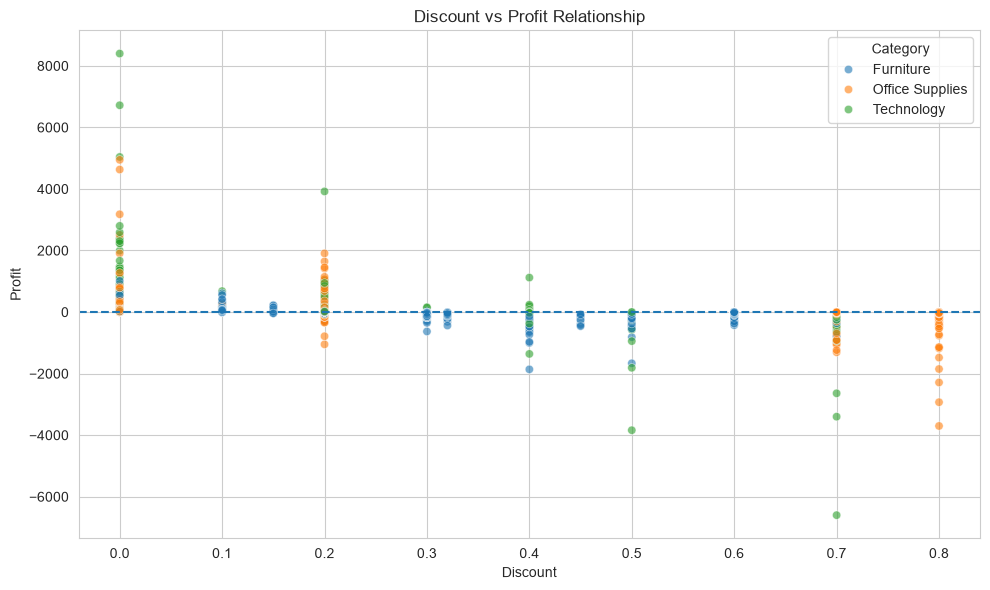

In [84]:
fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue= "Category",
    alpha=0.6,
    ax=ax
)
ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5
)

ax.set_title("Discount vs Profit Relationship")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")

ax.legend(title="Category")

plt.tight_layout()

plt.savefig(
    "../images/discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:

highest_discount = df["Discount"].max()

most_profitable_discount_range = (
    discount_analysis["Average_Profit"].idxmax()
)

least_profitable_discount_range = (
    discount_analysis["Average_Profit"].idxmin()
)

least_profitable_discount_value = (
    discount_analysis["Average_Profit"].min()
)

highest_profit_category = (
    high_discount_category["Average_Profit"].idxmax()
    if not high_discount_category.empty
    else "N/A"
)

lowest_profit_category = (
    high_discount_category["Average_Profit"].idxmin()
    if not high_discount_category.empty
    else "N/A"
)

print("=== DISCOUNT & PROFITABILITY KEY FINDINGS ===")

print(
    f"Discount vs Profit Correlation: "
    f"{discount_profit_corr:.3f}"
)

print(
    f"Discount vs Sales Correlation: "
    f"{discount_sales_corr:.3f}"
)

print(
    f"Sales vs Profit Correlation: "
    f"{sales_profit_corr:.3f}"
)

print(
    f"Quantity vs Sales Correlation: "
    f"{quantity_sales_corr:.3f}"
)

print(
    f"Most Profitable Discount Range: "
    f"{most_profitable_discount_range}"
)

print(
    f"Least Profitable Discount Range: "
    f"{least_profitable_discount_range} "
    f"(${least_profitable_discount_value:,.2f} average profit)"
)

print(
    f"Category with Highest Average Profit "
    f"under High Discounts: {highest_profit_category}"
)

print(
    f"Category with Lowest Average Profit "
    f"under High Discounts: {lowest_profit_category}"
)

print(
    f"Maximum Discount in Dataset: "
    f"{highest_discount:.2%}"
)

=== DISCOUNT & PROFITABILITY KEY FINDINGS ===
Discount vs Profit Correlation: -0.219
Discount vs Sales Correlation: -0.028
Sales vs Profit Correlation: 0.479
Quantity vs Sales Correlation: 0.201
Most Profitable Discount Range: No Discount
Least Profitable Discount Range: High Discount ($-106.71 average profit)
Category with Highest Average Profit under High Discounts: Office Supplies
Category with Lowest Average Profit under High Discounts: Technology
Maximum Discount in Dataset: 80.00%


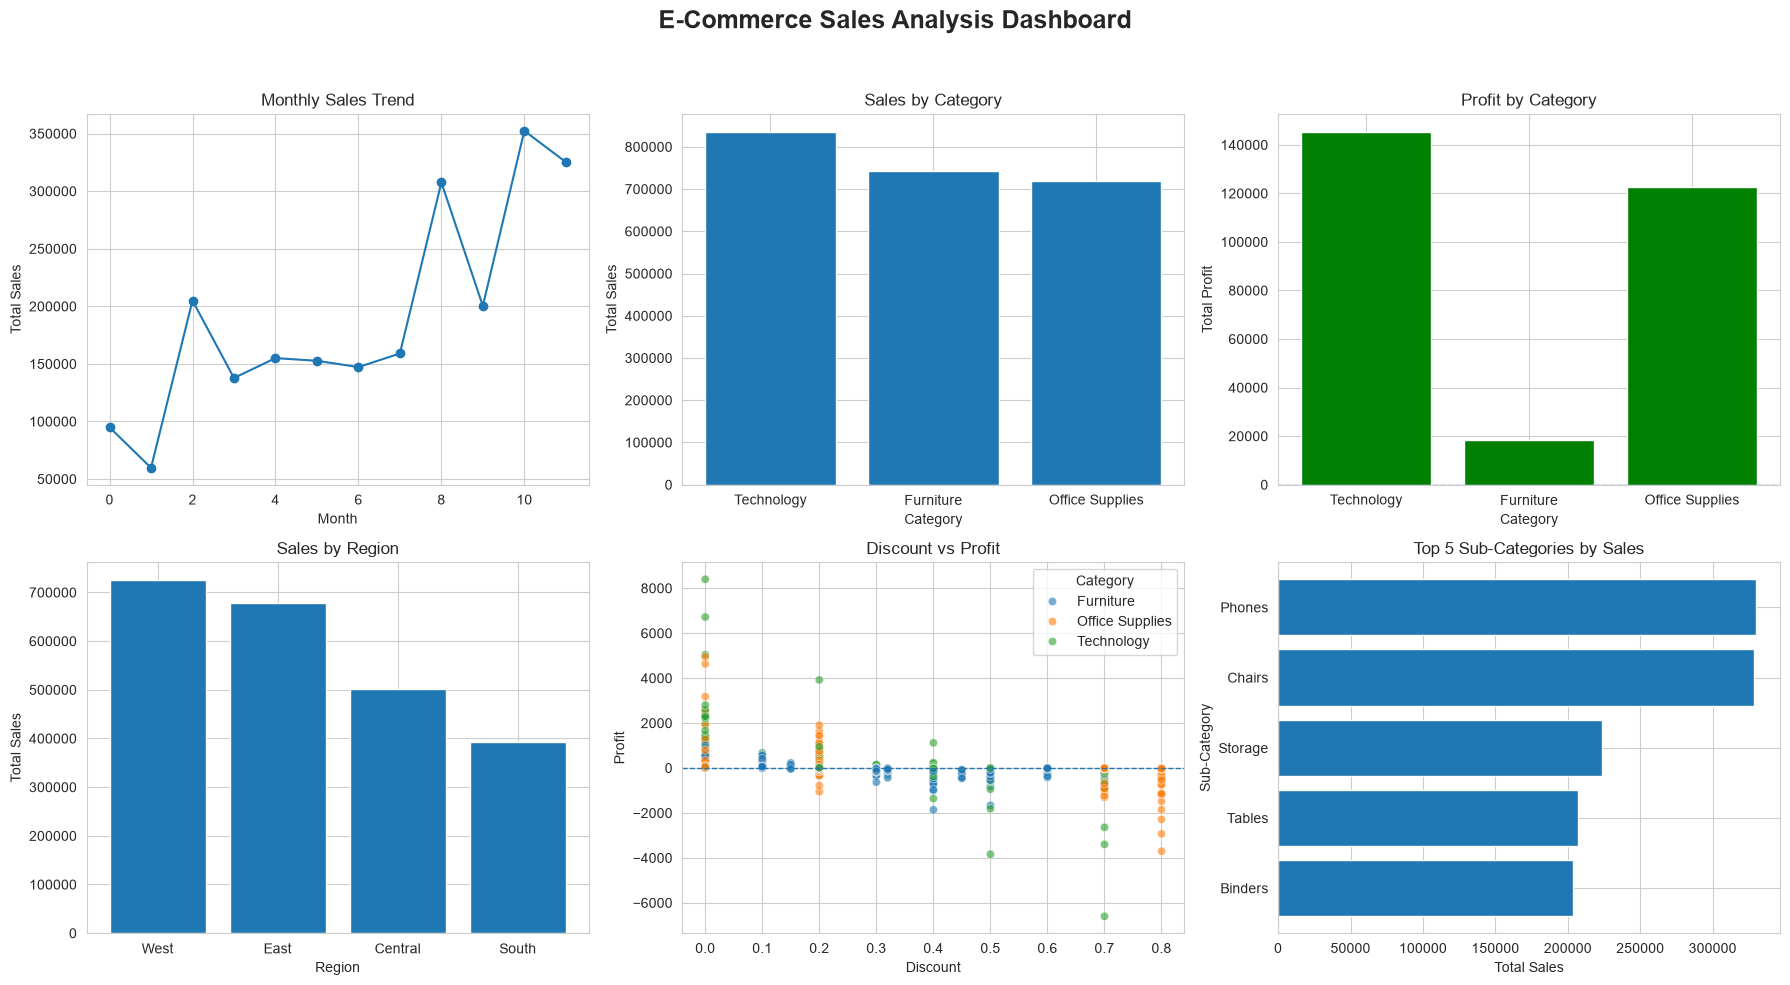

In [90]:
# ============================================================
# SECTION 13 — VISUALIZATIONS SUMMARY
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    "E-Commerce Sales Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)


# ------------------------------------------------------------
# Plot 1 — Monthly Sales Trend
# ------------------------------------------------------------

axes[0, 0].plot(
    monthly_performance.index,
    monthly_performance["Total_Sales"],
    marker="o"
)

axes[0, 0].set_title("Monthly Sales Trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Total Sales")


# ------------------------------------------------------------
# Plot 2 — Sales by Category
# ------------------------------------------------------------

axes[0, 1].bar(
    category_analysis.index,
    category_analysis["Total_Sales"]
)

axes[0, 1].set_title("Sales by Category")
axes[0, 1].set_xlabel("Category")
axes[0, 1].set_ylabel("Total Sales")


# ------------------------------------------------------------
# Plot 3 — Profit by Category
# ------------------------------------------------------------

category_profit = category_analysis["Total_Profit"]

profit_colors = [
    "green" if value >= 0 else "red"
    for value in category_profit
]

axes[0, 2].bar(
    category_profit.index,
    category_profit.values,
    color=profit_colors
)

axes[0, 2].axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

axes[0, 2].set_title("Profit by Category")
axes[0, 2].set_xlabel("Category")
axes[0, 2].set_ylabel("Total Profit")


# ------------------------------------------------------------
# Plot 4 — Sales by Region
# ------------------------------------------------------------

axes[1, 0].bar(
    regional_analysis.index,
    regional_analysis["Total_sales"]
)

axes[1, 0].set_title("Sales by Region")
axes[1, 0].set_xlabel("Region")
axes[1, 0].set_ylabel("Total Sales")


# ------------------------------------------------------------
# Plot 5 — Discount vs Profit
# ------------------------------------------------------------

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6,
    ax=axes[1, 1]
)

axes[1, 1].axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

axes[1, 1].set_title("Discount vs Profit")
axes[1, 1].set_xlabel("Discount")
axes[1, 1].set_ylabel("Profit")


# ------------------------------------------------------------
# Plot 6 — Top 5 Sub-Categories by Sales
# ------------------------------------------------------------

top_5_subcategories = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=True)
    .tail(5)
)

axes[1, 2].barh(
    top_5_subcategories.index,
    top_5_subcategories.values
)

axes[1, 2].set_title("Top 5 Sub-Categories by Sales")
axes[1, 2].set_xlabel("Total Sales")
axes[1, 2].set_ylabel("Sub-Category")


# ------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    "../images/analysis_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#  Section 14 — Key Business Insights

## 1.  Sales Performance Insights

-  The business generated total sales of **USD 2,297,200.86** and total profit of **USD 286,397.02**, resulting in an overall profit margin of **12.47%**. This indicates that the business is profitable overall while still having opportunities to improve profitability.

-  **Technology** generated the highest sales at **USD 836,154.03** and the highest profit at **USD 145,454.95**, making it the strongest overall category and the biggest contributor to business performance.

-  The business recorded **5,009 unique orders** from **793 unique customers**, with an average order value of approximately **USD 458.61**. This suggests that increasing repeat purchases and larger order sizes could further improve revenue.


## 2. 📅 Time & Seasonal Insights

-  **November** recorded the highest monthly sales at approximately **USD 352,461**, indicating strong year-end demand. The business should prepare additional inventory and marketing campaigns before this peak period.

-  **February** recorded the lowest monthly sales at approximately **USD 59,751**, highlighting a weaker sales period. Targeted promotions during this month could help reduce seasonal declines.

-  **2017** was the strongest year, generating approximately **USD 733,215.26** in sales and **USD 93,439.27** in profit. The growth achieved during this year can serve as a benchmark for future business strategies.


## 3.  Product & Category Insights

-  **Technology** generated approximately **USD 145,454.95** in total profit, substantially outperforming the other categories. This makes Technology the most valuable category for long-term profitability.

-  **Tables** generated a total loss of **USD 17,725.48**, while **Bookcases** lost **USD 3,472.55** and **Supplies** lost **USD 1,189.09**. These sub-categories require review of pricing, costs, and discount policies.

-  **Phones** generated approximately **USD 330,007** in sales, making it the highest-selling sub-category. Prioritizing high-demand products like Phones can help maximize revenue growth.


## 4.  Customer Insights

-  The dataset contains **793 unique customers** who placed **5,009 unique orders**, resulting in an average of approximately **6.32 orders per customer**. This demonstrates the importance of repeat customers in overall business performance.

-  The customer base generated approximately **USD 2.30 million** in sales, equivalent to around **USD 2,897** in average lifetime sales per customer. Improving customer retention could significantly increase long-term revenue.

-  **Tamara Chand** generated approximately **USD 8,981.32** in profit, whereas some high-sales customers such as **Sean Miller** generated a loss of approximately **USD 1,980.74**. This shows that high customer spending does not always guarantee profitability.


## 5.  Geographic Insights

-  The **West** region generated the highest sales at **USD 725,457.82** and the highest profit at **USD 108,418.45**, making it the strongest geographic market and an important region for future investment.

-  The **Central** region generated approximately **USD 501,239.89** in sales but only **USD 39,706.36** in profit, while the **South** generated lower sales but higher profit. This suggests that stronger sales do not always result in better profitability and Central deserves further investigation.


## 6.  Discount & Profitability Insights

-  The correlation between **Discount and Profit** was **-0.219**, indicating a negative relationship where increasing discounts generally reduce profitability. The business should carefully manage discount strategies to protect profit margins.

-  The correlation between **Discount and Sales** was **-0.028**, which is very close to zero. This suggests that larger discounts do not significantly increase sales, making aggressive discounting less effective as a growth strategy.

-  **Furniture** generated approximately **USD 741,999.80** in sales but only **USD 18,451.27** in profit, resulting in a very low profit margin of around **2.49%** compared to Technology's much stronger profitability. The business should focus on improving Furniture pricing and discount management rather than only increasing its 

# **Section 15 — Conclusion

This project analyzed the E-Commerce Sales & Customer dataset to understand overall sales performance, profitability, customer behavior, product performance, geographic trends, time-based patterns, and the impact of discounts. The business generated total sales of **USD 2,297,200.86** and total profit of **USD 286,397.02**, with an overall profit margin of **12.47%**. Technology was the strongest category, generating **USD 836,154.03** in sales and **USD 145,454.95** in profit. West was the best-performing region with **USD 725,457.8**2 in sales, while Tables was a major profitability concern with a loss of **USD 17,725.48**. The analysis also found that November was the strongest month, generating approximately **USD 352,461** in sales, indicating an important seasonal pattern. Discount analysis showed a correlation of **-0.219** between discount and profit, highlighting the need for careful discount management. Based on these findings, the business should prioritize high-performing products and regions, improve low-profit or loss-making areas, strengthen customer retention, and use discounts more strategically. Future analysis could extend this project through customer churn prediction, geographic heatmaps, customer lifetime value analysis, and machine learning-based customer segmentation.